# Algorithmic Trading Backtester — Exploration

This notebook runs all strategies end to end, compares their performance, and visualises the results.

## 1. Setup & Imports

In [1]:
import sys
sys.path.insert(0, "../src")

import pandas as pd
import matplotlib.pyplot as plt

from data import DataLoader
from backtest import BackTester, BackTestResult
from strategies import (
    MovingAverageCrossover,
    MomentumStrategy,
    MeanReversionStrategy,
    RSIStrategy,
    BollingerBandBreakoutStrategy,
    MACDStrategy,
    VolatilityBreakoutStrategy
)
from metrics import metric_summary

print("All imports loaded successfully")

All imports loaded successfully


## 2. Load Data

In [2]:
loader = DataLoader()
data = loader.get_price_history("AAPL", start="2018-01-01", end="2024-01-01")

print(f"Loaded {len(data)} rows of data")
print(f"Date range: {data.index[0].date()} to {data.index[-1].date()}")
data.head()

Loaded 1509 rows of data
Date range: 2018-01-02 to 2023-12-29


,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2018-01-02 00:00:00-05:00,39.776190,40.276431,39.565806,40.267078,102223600,0.0,0.0
2018-01-03 00:00:00-05:00,40.330191,40.802382,40.196951,40.260063,118071600,0.0,0.0
2018-01-04 00:00:00-05:00,40.332521,40.549917,40.224995,40.447063,89738400,0.0,0.0
2018-01-05 00:00:00-05:00,40.542920,40.994071,40.451755,40.907581,94640000,0.0,0.0
2018-01-08 00:00:00-05:00,40.755630,41.050164,40.657449,40.755630,82271200,0.0,0.0


## 3. Run a Single Strategy (Quick Sanity Check)

Test one strategy first before running all 8.

In [3]:
strategy = MovingAverageCrossover()
backtester = BackTester(starting_capital=10_000)
result = backtester.run_backtest(data, strategy)

print("Equity curve (last 5 days):")
print(result.equity_curve.tail())
print(f"\nFinal portfolio value: ${result.equity_curve.iloc[-1]:,.2f}")
print(f"Number of trades: {len(result.trades)}")

Equity curve (last 5 days):
Date
2023-12-22 00:00:00-05:00    22353.459609
2023-12-26 00:00:00-05:00    22289.957887
2023-12-27 00:00:00-05:00    22301.500091
2023-12-28 00:00:00-05:00    22351.152238
2023-12-29 00:00:00-05:00    22229.912769
Name: Close, dtype: float64

Final portfolio value: $22,229.91
Number of trades: 7


## 4. Run All Strategies & Compare

In [4]:
strategies = {
    "MA Crossover": MovingAverageCrossover(),
    "Momentum": MomentumStrategy(),
    "Mean Reversion": MeanReversionStrategy(),
    "RSI": RSIStrategy(),
    "Bollinger Band": BollingerBandBreakoutStrategy(),
    "MACD": MACDStrategy(),
    "Volatility Breakout": VolatilityBreakoutStrategy()
}

backtester = BackTester(starting_capital=10_000)
results = {}
summaries = {}

for name, strategy in strategies.items():
    result = backtester.run_backtest(data, strategy)
    results[name] = result
    summaries[name] = metric_summary(result)
    print(f"Finished: {name}")

comparison = pd.DataFrame(summaries).T
comparison.round(4)

Finished: MA Crossover
Finished: Momentum
Finished: Mean Reversion
Finished: RSI
Finished: Bollinger Band
Finished: MACD
Finished: Volatility Breakout


,Total Return,Sharpe Ratio,Max Drawdown,Win Rate,Annualised Volatility
MA Crossover,1.2230,0.6289,-43.3321,0.5259,0.2706
Momentum,3.4924,1.3314,-25.4223,0.5347,0.2043
Mean Reversion,0.2478,0.4264,-8.3238,0.4915,0.0976
RSI,0.5837,1.0073,-4.1673,0.6122,0.0793
Bollinger Band,0.0163,0.0753,-13.2791,0.5049,0.0592
MACD,3.3390,1.3778,-26.7405,0.5472,0.1914
Volatility Breakout,-0.1968,-0.4855,-22.3583,0.4474,0.0701


## 5. Equity Curves — All Strategies vs Buy & Hold

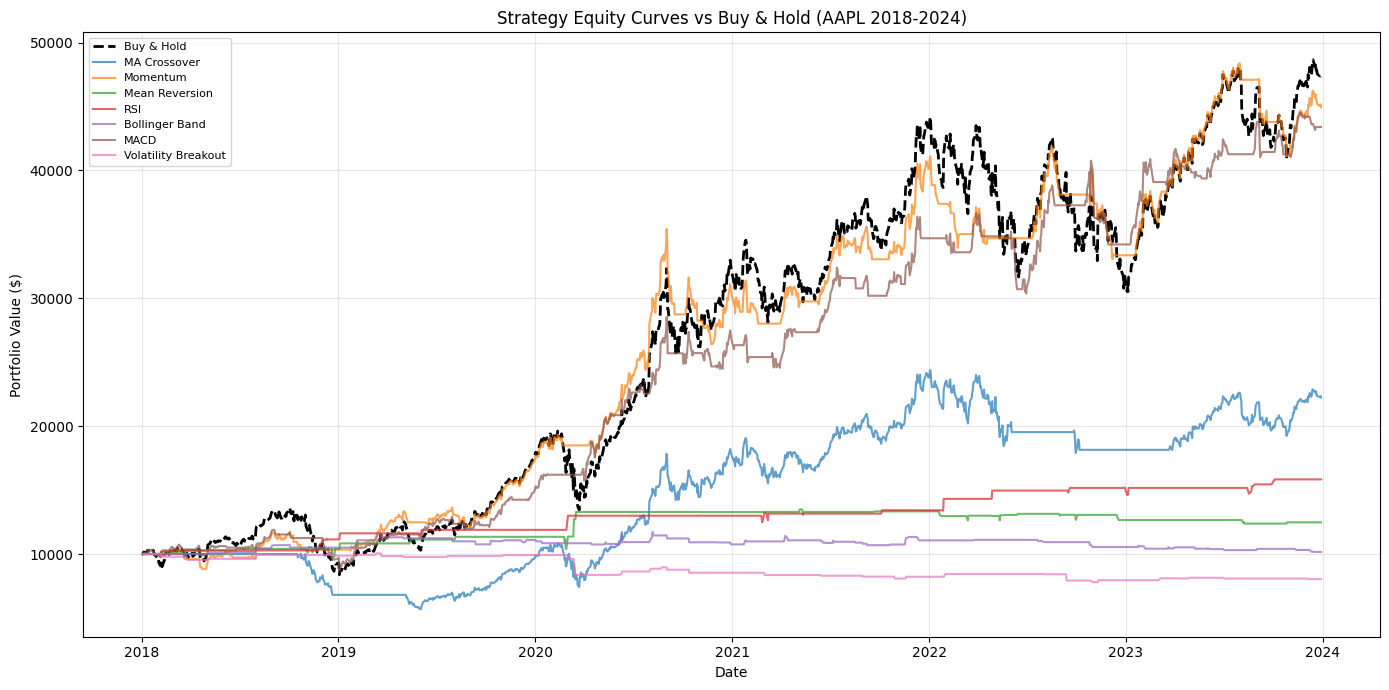

In [5]:
buy_hold_returns = data["Close"].pct_change().fillna(0)
buy_hold_curve = 10_000 * (1 + buy_hold_returns).cumprod()

plt.figure(figsize=(14, 7))
plt.plot(buy_hold_curve.index, buy_hold_curve, label="Buy & Hold", linewidth=2, color="black", linestyle="--")

for name, result in results.items():
    plt.plot(result.equity_curve.index, result.equity_curve, label=name, alpha=0.7)

plt.title("Strategy Equity Curves vs Buy & Hold (AAPL 2018-2024)")
plt.xlabel("Date")
plt.ylabel("Portfolio Value ($)")
plt.legend(loc="upper left", fontsize=8)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Drawdown — Worst Strategy Periods

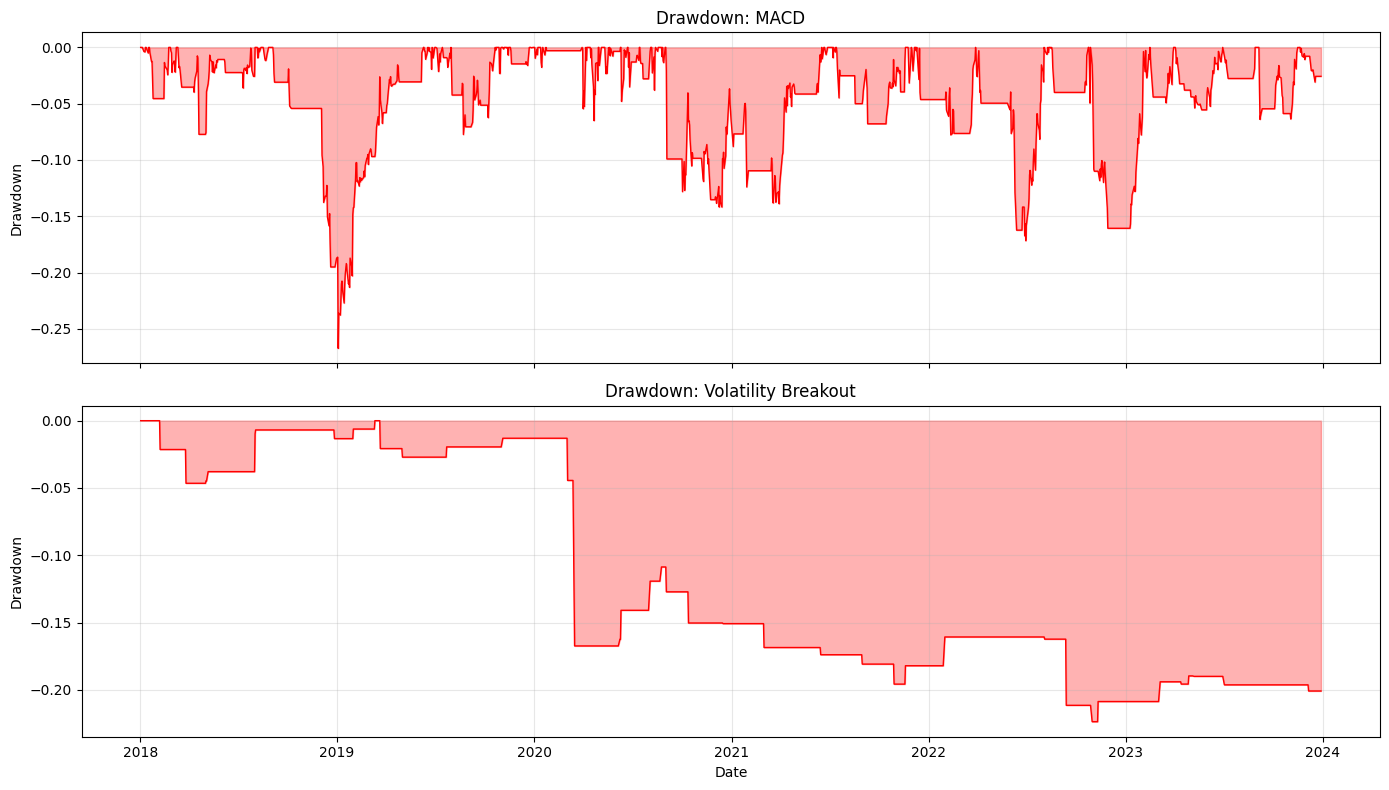

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Best performing strategy by Sharpe
best_name = comparison["Sharpe Ratio"].idxmax()
best_result = results[best_name]

# Worst performing strategy by Sharpe
worst_name = comparison["Sharpe Ratio"].idxmin()
worst_result = results[worst_name]

for ax, name, result in [(axes[0], best_name, best_result), (axes[1], worst_name, worst_result)]:
    cummax = result.equity_curve.cummax()
    drawdown = (result.equity_curve - cummax) / cummax
    ax.fill_between(drawdown.index, drawdown, 0, color="red", alpha=0.3)
    ax.plot(drawdown.index, drawdown, color="red", linewidth=1)
    ax.set_title(f"Drawdown: {name}")
    ax.set_ylabel("Drawdown")
    ax.grid(alpha=0.3)

plt.xlabel("Date")
plt.tight_layout()
plt.show()

## 7. Strategy Comparison Bar Charts

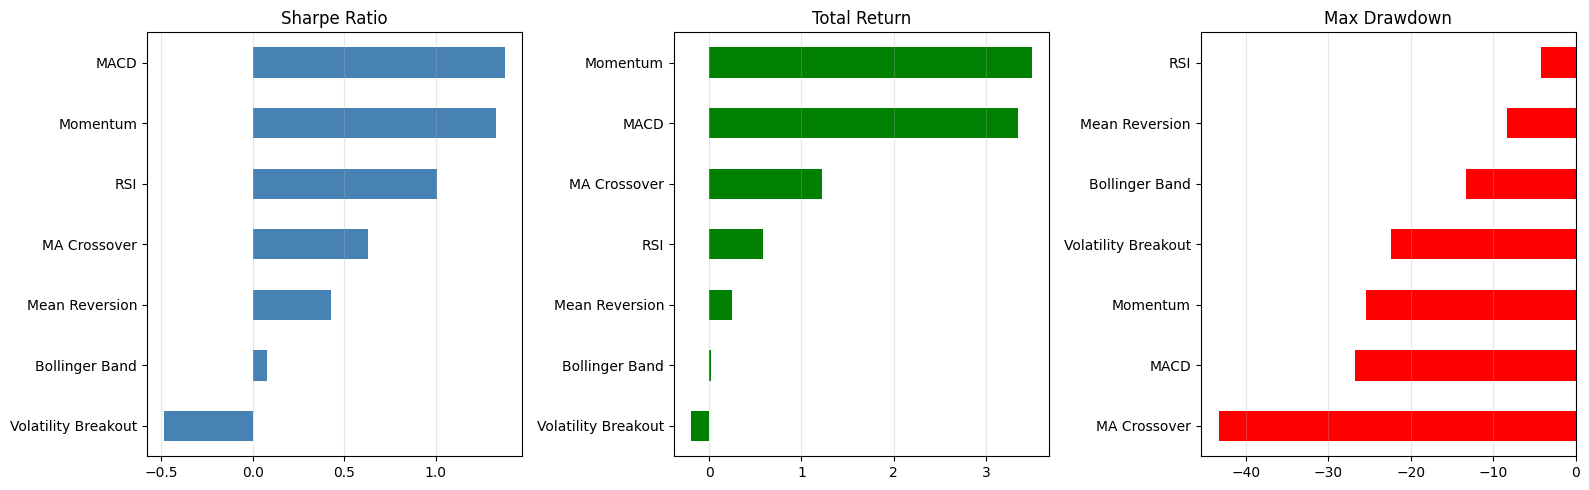

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

metrics_to_plot = ["Sharpe Ratio", "Total Return", "Max Drawdown"]
colours = ["steelblue", "green", "red"]

for ax, metric, colour in zip(axes, metrics_to_plot, colours):
    comparison[metric].sort_values().plot(kind="barh", ax=ax, color=colour)
    ax.set_title(metric)
    ax.grid(alpha=0.3, axis="x")

plt.tight_layout()
plt.show()

## 8. Test on a Different Ticker

Run the best strategy on a different stock to see if the results hold up.

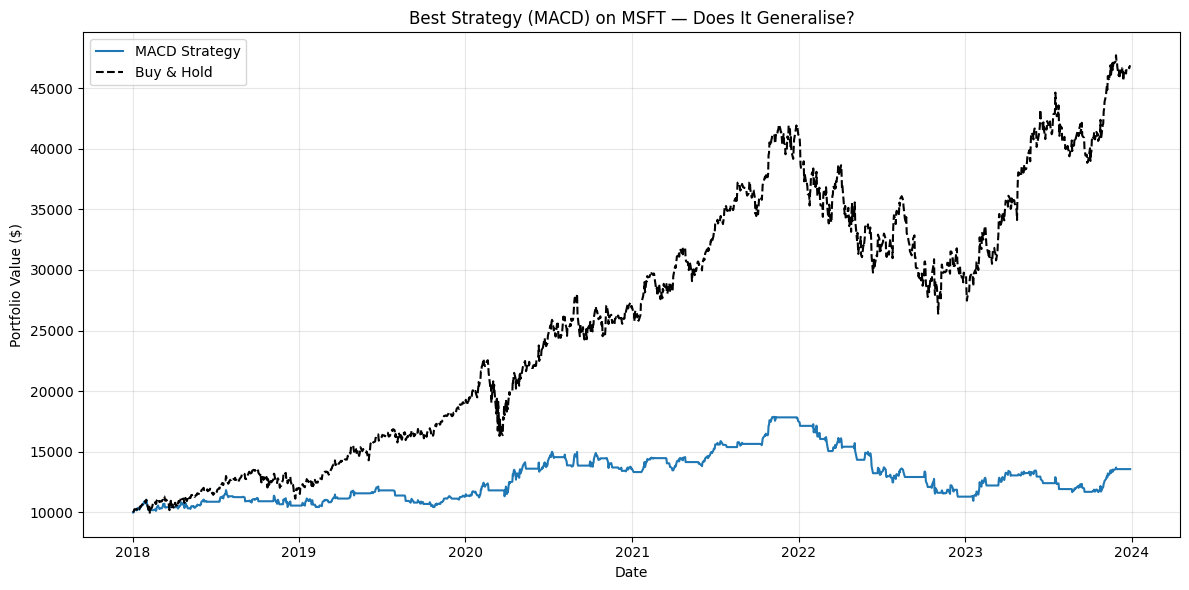


--- MACD on MSFT ---
Total Return              0.3575
Sharpe Ratio              0.3654
Max Drawdown            -38.7432
Win Rate                  0.5236
Annualised Volatility     0.1884
dtype: float64


In [10]:
msft_data = loader.get_price_history("MSFT", start="2018-01-01", end="2024-01-01")

best_strategy = strategies[best_name]
msft_result = backtester.run_backtest(msft_data, best_strategy)

msft_buy_hold = 10_000 * (1 + msft_data["Close"].pct_change().fillna(0)).cumprod()

plt.figure(figsize=(12, 6))
plt.plot(msft_result.equity_curve.index, msft_result.equity_curve, label=f"{best_name} Strategy")
plt.plot(msft_buy_hold.index, msft_buy_hold, label="Buy & Hold", linestyle="--", color="black")
plt.title(f"Best Strategy ({best_name}) on MSFT — Does It Generalise?")
plt.xlabel("Date")
plt.ylabel("Portfolio Value ($)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\n--- {best_name} on MSFT ---")
print(metric_summary(msft_result).round(4))

## 9. Save Results

In [ ]:
comparison.round(4).to_csv("../comparison_results.csv")
print("Saved comparison_results.csv")
print("\nFinal comparison table:")
comparison.round(4)